Cancer treatment as Contextual Bandit

Following class encapsulates UCB calculation for a context and also updates reward. 

We take alpha as 1.5 as it yielded better results in various iterations of testing.



In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pdb
import seaborn as sns
import pandas as pd


# Create class object for a single linear ucb disjoint arm
class linucb_dis_canc_treatment():
    
    def __init__(self, arm_index, d, alpha):
        
        # Track arm index
        self.arm_index = arm_index
        
        # Keep track of alpha
        self.alpha = alpha
        
        # A: (d x d) matrix = D_a.T * D_a + I_d. 
        # The inverse of A is used in ridge regression 
        self.A = np.identity(d)
        
        # b: (d x 1) corresponding response vector. 
        # Equals to D_a.T * c_a in ridge regression formulation
        self.b = np.zeros([d,1])
        
    def calc_UCB(self, x_array):
        # Find A inverse for ridge regression
        A_inv = np.linalg.inv(self.A)
        
        # Perform ridge regression to obtain estimate of covariate coefficients theta
        # theta is (d x 1) dimension vector
        self.theta = np.dot(A_inv, self.b)
        
        # Reshape covariates input into (d x 1) shape vector
        x = x_array.reshape([-1,1])
        #print("x shape", x.shape)
        #print("theta.T shape", self.theta.T.shape)
        # Find ucb based on p formulation (mean + std_dev) 
        # p is (1 x 1) dimension vector
        p = np.dot(self.theta.T,x) +  self.alpha * np.sqrt(np.dot(x.T, np.dot(A_inv,x)))
        
        return p
    
    def reward_update(self, reward, x_array):
        # Reshape covariates input into (d x 1) shape vector
        x = x_array.reshape([-1,1])
        
        # Update A which is (d * d) matrix.
        self.A += np.dot(x, x.T)
        
        # Update b which is (d x 1) vector
        # reward is scalar
        self.b += reward * x

Linear UCB policy class which provides functionality of selection of arm based on the UCB calculation. 
Higher UCB will be given priority and in case of random tie-breaks, select it. 

To have sufficient balance between exploration and exploitation, random selection is done from the treatment arm which so far have yielded 

In [2]:
class linucb_policy():
    
    def __init__(self, K_arms, d, alpha):
        self.K_arms = K_arms
        self.linucb_arms = [linucb_dis_canc_treatment(arm_index = 1, d = d, alpha = alpha) for i in range(K_arms)]
        
    def select_arm(self, x_array):
        # Initiate ucb to be 0
        highest_ucb = -1
        
        # Track index of arms to be selected on if they have the max UCB.
        candidate_arms = []
        #print("K_arms" ,self.K_arms )
        for arm_index in range(self.K_arms):
            # Calculate ucb based on each arm using current covariates at time t
            arm_ucb = self.linucb_arms[arm_index].calc_UCB(x_array)
            
            # If current arm is highest than current highest_ucb
            if arm_ucb > highest_ucb:
                
                # Set new max ucb
                highest_ucb = arm_ucb
                
                # Reset candidate_arms list with new entry based on current arm
                candidate_arms.append(arm_index)

            # If there is a tie, append to candidate_arms
            if arm_ucb == highest_ucb:
                
                candidate_arms.append(arm_index)
        
        # Choose based on candidate_arms randomly (tie breaker)
        selected_arm = np.random.choice(candidate_arms)
        #selected_arm = np.argmax(candidate_arms , axis=0)
        #print("chosen_arm", candidate_arms)
        return selected_arm

Following are 2 utility functions. 

action_arm_map --> this function will return the Treatment arm index , when input was a treatment arm. 

arm_action_map --> this function will return the Treatment arm , when input was a treatment arm index.
These functions are needed, because linear UCB will return an arm index for selected option. 

In [3]:
def action_arm_map(int_arm):
    if int_arm == 1:
        return "Chemotherapy"
    if int_arm == 2:
        return "Harmone Therapy"
    if int_arm == 3:
        return "Radiation Therapy"
    if int_arm == 4:
        return "Surgery"
    
def arm_action_map(arm):
    if arm == "Chemotherapy":
        return 1
    if arm == "Harmone Therapy":
        return 2
    if arm == "Radiation Therapy":
        return 3
    if arm == "Surgery":
        return 4

# Problem Formulation : Cancer Treatment as Contextual Bandit Problem

Given problem can be formulated as Contextual Bandit problem. 
Each cancer treatment is formalized as an ARM in this problem. 

ARMS : Treatment Type : Chemotherapy, Surgery, Radiation Therapy, Harmone Therapy
So, we see that there are 4 available ARMs. 
Contextual Information: Characteristic information like radius, texture, smoothness, compactness etc are the context that describes  

Reward : No reward if selected ARM had failed treatment. 
Given data set gives samples where for certain characteristics, a treatment arm was selected. Its status of treatment is also recorded as 0 or 1. 

Additionally, cost incurred in the treatment is recorded. 
Hence, given problem aptly falls in category of Contextual Bandit problem, in which using context an optimal action would be determined based on the reward generated. 

Problem Solution

Contextual Bandit problem can be solved using various algorithms. In this case, we are using Liner UCB to solve and arrive at stable policy which guarantees good results. 

Linear UCB : Linear Upper Confidence Bound (LinUCB)

Step1 : Select a sample from given data set. 
Step2 : For this sample, fetch out the context 
Step 3 : For this context,  calculate UCB for each ARM
Step 4 : Add to the action list if newly calculated UCB is higher than already available one 
Step5 : Out of available action list, make a selection. 


Main controller function. Provides functionality to parse dataset and go for each sample and calls to select and arm

Below function is main controller function which will : 

-> select context and map it to a treatment arm
   For mapping of context to an action, it calls linear UCB. 

-> check if this arm resulted in SUCCESS or FAIL
   For returned treatment arm, we check the Treatment Status to determine if it was SUCCESS or FAIL.

-> generate reward based on treatmemt-status and Resources utilized (more the resource allocation, lesser is reward generation)
   

In [4]:

def canc_tr_simul(K_arms, d, alpha):
    # Initiate policy
    linucb_policy_object = linucb_policy(K_arms = K_arms, d = d, alpha = alpha)
    
    # Instantiate trackers
    aligned_time_steps = 0
    cumulative_rewards = 0
    aligned_ctr = []
    sel_arms = np.empty(4,dtype=int)
    sel_arms[0] = sel_arms[1] = sel_arms[2] = sel_arms[3] = 0
    unaligned_ctr = [] # for unaligned time steps
    
    
    # Open data
    #with open(data_path, "r") as f:
    df = pd.read_csv('./cancer.csv')
    df_original = df
    df = df.drop(['Treatment Type', 'Treatment status(0=Failure,1=Success)' , 'budget(in dollars)' , 'Time(In days)'], axis=1)
    #print(df.iloc[:2])
    n = df.shape[0]
    for i in range(0, n):
        if df.loc[i, 'diagnosis'] == 'M':
            df.loc[i, 'diagnosis'] = 1.0
        else:
            df.loc[i, 'diagnosis'] = 2.0
        
    for i in range(0, n):

            #save the treatment arm based on the current sample 
            data_arm = df_original.loc[i, 'Treatment Type']
            #print("data_arm" , data_arm)

            # for this, get the reward. Reward calculation is : if it was success treatment, cumulative of money and time
            if df_original.loc[i, 'Treatment status(0=Failure,1=Success)'] == 0:                
                data_reward = 0
            else:
                data_reward = 1/((df_original.loc[i, 'budget(in dollars)'] + df_original.loc[i, 'Time(In days)']))*10000000


            data_x_array = df.loc[i].to_numpy(dtype=float)
            #print("data shape", data_x_array.shape , data_x_array.dtype, data_x_array)

            # Find policy's chosen arm based on input covariates at current time step
            arm_index = linucb_policy_object.select_arm(data_x_array)
            data_arm_returned = action_arm_map(arm_index+1)
            #print("data_arm" , data_arm_returned)
            # Check if arm_index is the same as data_arm (ie same actions were chosen)
            #if data_arm_returned == data_arm:

                # Use reward information for the chosen arm to update
            linucb_policy_object.linucb_arms[arm_index].reward_update(data_reward, data_x_array)

                # For correct selection calculation
            sel_arms[arm_index] = sel_arms[arm_index] + 1 
            aligned_time_steps += 1
            cumulative_rewards += data_reward
            aligned_ctr.append(cumulative_rewards/aligned_time_steps)
    
    most_aff_arm = np.argmax(sel_arms, axis=0)
    arm_ = action_arm_map(most_aff_arm+1)
    print("##Most effective arm             =" , arm_ )
    print("##Number of time it ws exploited = " , sel_arms[most_aff_arm] )
    print("##Number of time it ws explored  = " , 569 - sel_arms[most_aff_arm] )
    return (aligned_time_steps, cumulative_rewards, aligned_ctr, linucb_policy_object)

## Statistical Significance of Treatment arms



Below data shows Statistical Significance of Treatment arms in terms of Exploitation to maximize reward:

We have enumerated most affective treatment arm and how many times it got exploited.  

##Most effective arm             = Chemotherapy
##Number of time it ws exploited =  506
##Number of time it ws explored  =  63


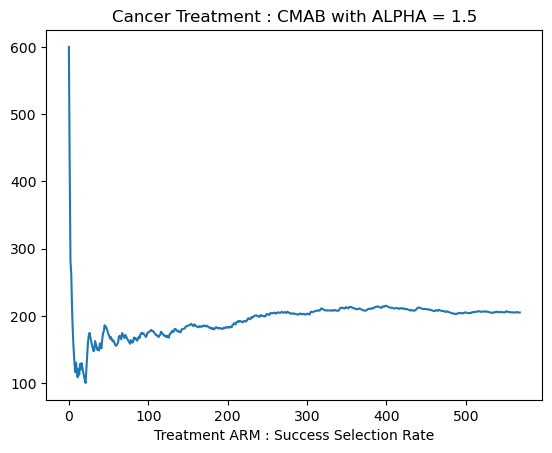

cum_rewards 116731.97946208852


In [5]:
alpha_input = 1.5
aligned_time_steps, cum_rewards, aligned_ctr, policy = canc_tr_simul(K_arms = 4, d = 11 , alpha = alpha_input)
plt.plot(aligned_ctr)
plt.xlabel('Treatment ARM : Success Selection Rate')
plt.title('Cancer Treatment : CMAB with ALPHA = 1.5')
plt.show()
print("cum_rewards", cum_rewards)
#print("aligned_ctr", aligned_ctr)